# Load and Combine the Data

In [15]:
import numpy as np
import pandas as pd

# 1. Load the merged dataset
df = pd.read_csv('email\data\email_final_merged.csv')

# 2. Handle nulls safely (fill with empty strings)
df['subject'] = df['subject'].fillna('')
df['body'] = df['body'].fillna('')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (35616, 3)


,subject,body,target
0,christmas tree farm pictures,,0.0
1,"vastar resources , inc .","gary , production from the high island larger ...",0.0
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,0.0
3,re : issue,fyi - see note below - already done .\nstella\...,0.0
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,0.0


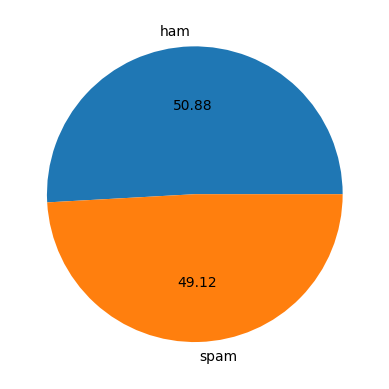

In [16]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

# Upgraded Text Preprocessing (HTML Stripping)

In [17]:
%pip install beautifulsoup4


Note: you may need to restart the kernel to use updated packages.


In [18]:
import time

import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from bs4 import BeautifulSoup 
from tqdm import tqdm # <-- 1. Import tqdm

# 2. Register tqdm with pandas
tqdm.pandas() 

nltk.download('punkt')
nltk.download('stopwords')

ps = PorterStemmer()

def transform_text(text):
    # If the text is somehow not a string, return an empty string
    if not isinstance(text, str):
        return ""
        
    # 1. Strip HTML tags
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ")
    
    # 2. Standardize case
    text = text.lower()
    
    # 3. Tokenize
    text = nltk.word_tokenize(text)
    
    # 4. Remove special characters
    y = [i for i in text if i.isalnum()]
    
    # 5. Remove stopwords and punctuation
    text = [i for i in y if i not in stopwords.words('english') and i not in string.punctuation]
    
    # 6. Stemming
    y = [ps.stem(i) for i in text]
            
    return " ".join(y)

def format_time(seconds):
    hours, remainder = divmod(seconds, 3600)
    minutes, seconds = divmod(remainder, 60)
    return f"{int(hours)}h {int(minutes)}m {seconds:.2f}s"

# --- 1. SUBJECT CLEANING ---
if 'clean_subject' not in df.columns:
    print("⏳ Cleaning Subjects...")
    start_subject = time.time()
    
    df['clean_subject'] = df['subject'].progress_apply(transform_text)
    df.to_csv(r"email\data\email_final_merged_clean_subjet.csv", index=False)
    
    subject_time = time.time() - start_subject
    print(f"✅ Cleaning Subjects took: {format_time(subject_time)}\n")
else:
    print("⏭️ 'clean_subject' already exists. Skipping subject cleaning.\n")


# --- 2. BODY CLEANING ---
if 'clean_body' not in df.columns:
    print("⏳ Cleaning Bodies...")
    start_body = time.time()
    
    df['clean_body'] = df['body'].progress_apply(transform_text)
    df.to_csv(r"email\data\email_final_merged_clean_subjet_and_body.csv", index=False)
    
    body_time = time.time() - start_body
    print(f"✅ Cleaning Bodies took: {format_time(body_time)}\n")
else:
    print("⏭️ 'clean_body' already exists. Skipping body cleaning.\n")

print("🎉 Text cleaning pipeline complete!")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\adars\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\adars\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


⏳ Cleaning Subjects...


100%|██████████| 35616/35616 [03:46<00:00, 157.51it/s]


✅ Cleaning Subjects took: 0h 3m 47.16s

⏳ Cleaning Bodies...


100%|██████████| 35616/35616 [2:45:57<00:00,  3.58it/s]   


✅ Cleaning Bodies took: 2h 45m 59.32s

🎉 Text cleaning pipeline complete!


In [19]:
df.columns

Index(['subject', 'body', 'target', 'clean_subject', 'clean_body'], dtype='object')

🎨 Generating text corpuses...
☁️ Building Word Clouds...


C:\Users\adars\AppData\Local\Temp\ipykernel_10236\1949123309.py:46: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=3.0)
C:\Users\adars\AppData\Local\Temp\ipykernel_10236\1949123309.py:46: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=3.0)
c:\Users\adars\.conda\envs\college\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\adars\.conda\envs\college\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


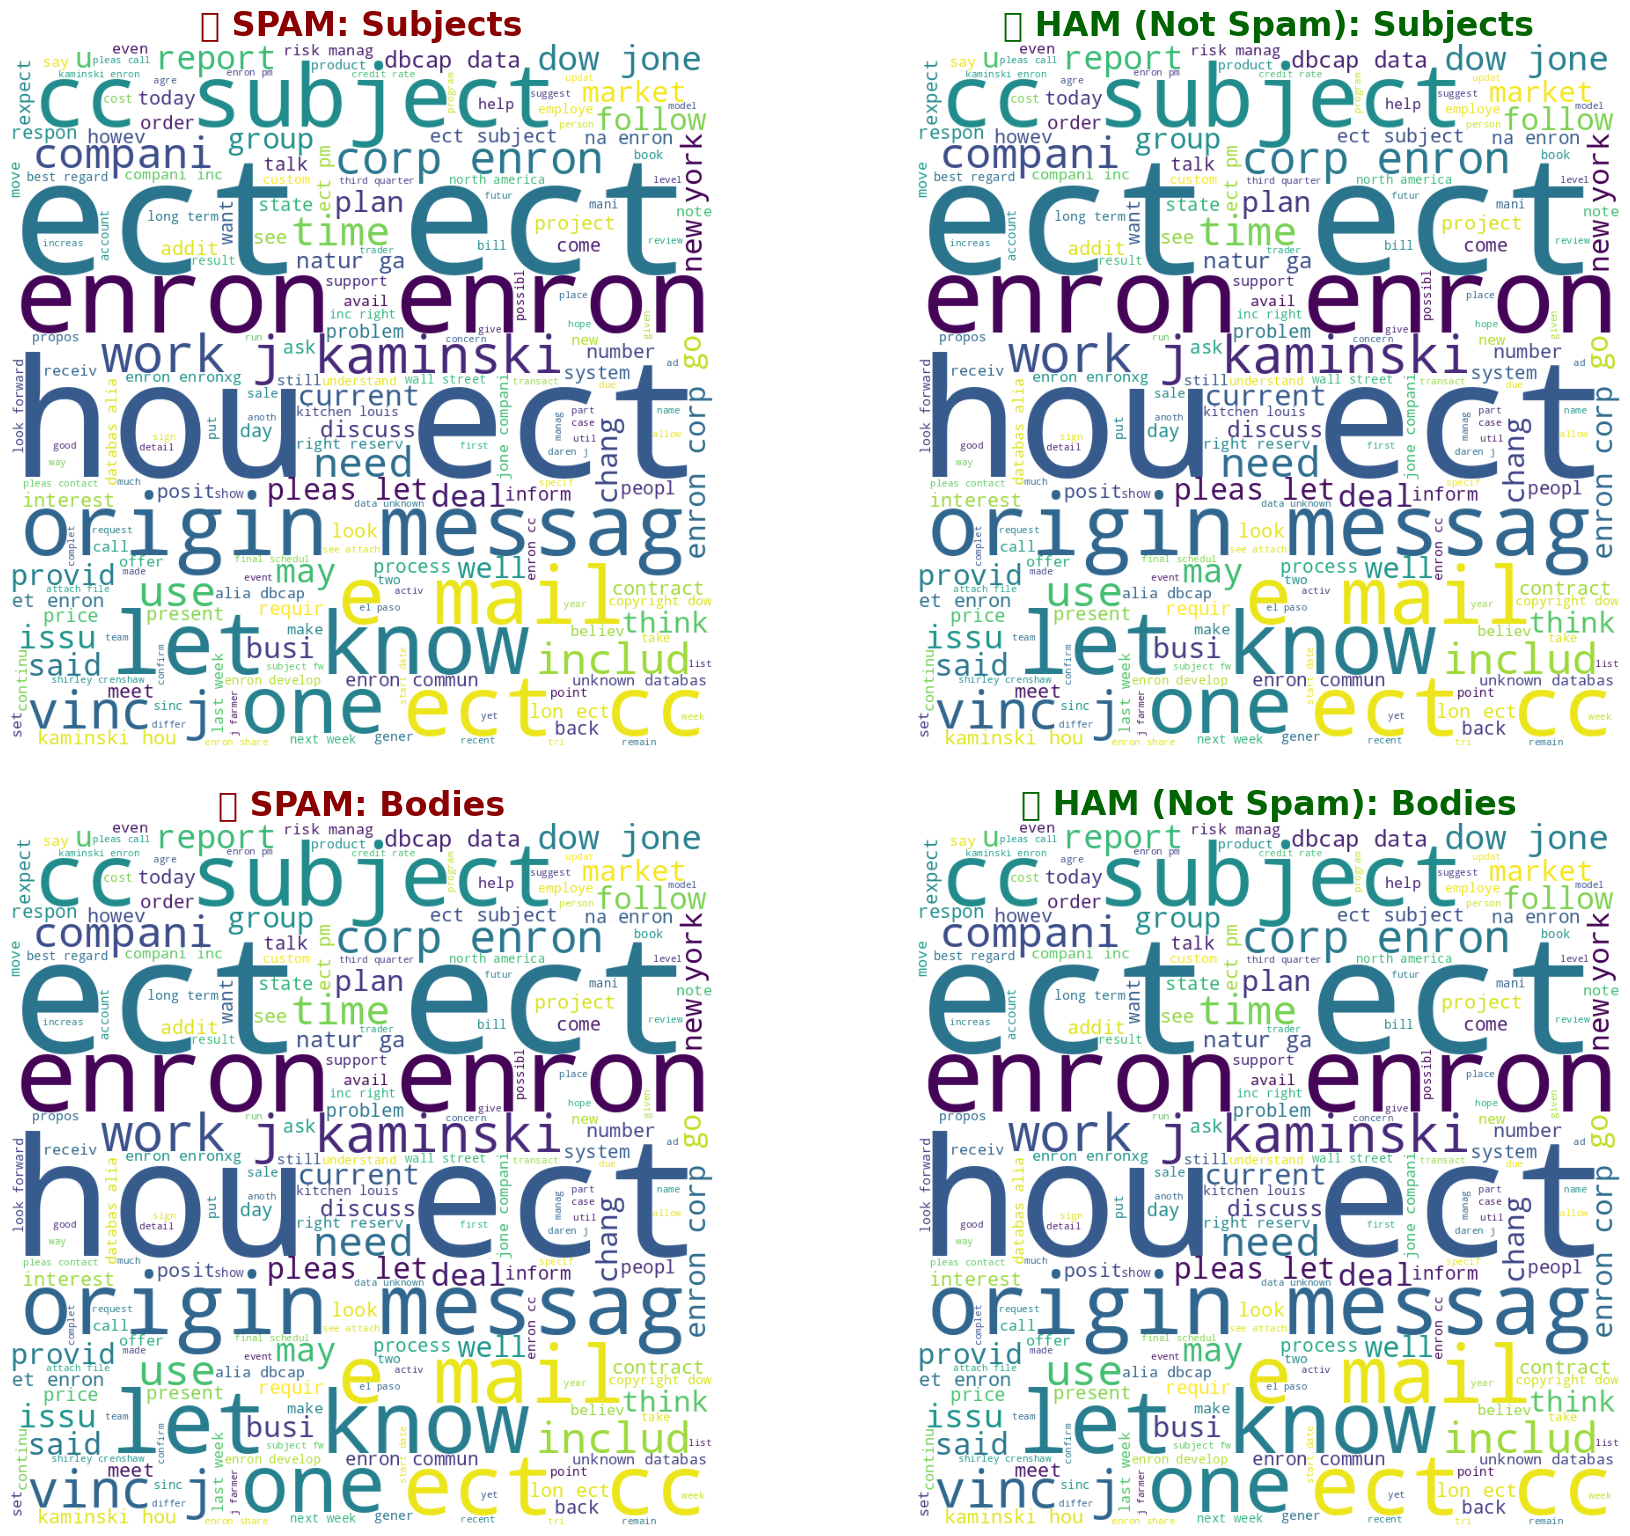

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Initialize the WordCloud object
wc = WordCloud(width=800, height=800, min_font_size=10, background_color='white')

print("🎨 Generating text corpuses...")
# 1. Combine the text for all 4 scenarios
spam_subject_text = df[df['target'] == 1]['clean_subject'].str.cat(sep=" ")
ham_subject_text = df[df['target'] == 0]['clean_subject'].str.cat(sep=" ")

spam_body_text = df[df['target'] == 1]['clean_body'].str.cat(sep=" ")
ham_body_text = df[df['target'] == 0]['clean_body'].str.cat(sep=" ")

print("☁️ Building Word Clouds...")
# 2. Generate the actual word clouds (with a tiny fallback just in case a column is entirely empty)
wc_spam_sub = wc.generate(spam_subject_text if spam_subject_text.strip() else "Empty")
wc_ham_sub = wc.generate(ham_subject_text if ham_subject_text.strip() else "Empty")
wc_spam_bod = wc.generate(spam_body_text if spam_body_text.strip() else "Empty")
wc_ham_bod = wc.generate(ham_body_text if ham_body_text.strip() else "Empty")

# 3. Plot them in a beautiful 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Top-Left: Spam Subjects
axes[0, 0].imshow(wc_spam_sub)
axes[0, 0].set_title('🚨 SPAM: Subjects', fontsize=24, color='darkred', fontweight='bold')
axes[0, 0].axis('off')

# Top-Right: Ham Subjects
axes[0, 1].imshow(wc_ham_sub)
axes[0, 1].set_title('✅ HAM (Not Spam): Subjects', fontsize=24, color='darkgreen', fontweight='bold')
axes[0, 1].axis('off')

# Bottom-Left: Spam Bodies
axes[1, 0].imshow(wc_spam_bod)
axes[1, 0].set_title('🚨 SPAM: Bodies', fontsize=24, color='darkred', fontweight='bold')
axes[1, 0].axis('off')

# Bottom-Right: Ham Bodies
axes[1, 1].imshow(wc_ham_bod)
axes[1, 1].set_title('✅ HAM (Not Spam): Bodies', fontsize=24, color='darkgreen', fontweight='bold')
axes[1, 1].axis('off')

# Adjust layout so titles don't overlap
plt.tight_layout(pad=3.0)
plt.show()

Dual Vectorization (Feature Stacking)

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialize TWO vectorizers
# 500 words for subject, 3000 words for the body
tfidf_subject = TfidfVectorizer(max_features=500)
tfidf_body = TfidfVectorizer(max_features=3000)

# 2. Vectorize them separately
print("⚙️ Vectorizing Subjects...")
X_subject = tfidf_subject.fit_transform(df['clean_subject']).toarray()

print("⚙️ Vectorizing Bodies...")
X_body = tfidf_body.fit_transform(df['clean_body']).toarray()

# 3. Stack them horizontally!
# This creates a single mega-array with 3500 columns per email
X_combined = np.hstack((X_subject, X_body))

y = df['target'].values

print(f"Final Feature Matrix Shape: {X_combined.shape}")

⚙️ Vectorizing Subjects...
⚙️ Vectorizing Bodies...
Final Feature Matrix Shape: (35616, 3500)


Train and Evaluate Models

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=2)

# Initialize models
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

clfs = {
    'SVC' : svc, 'KN' : knc, 'NB': mnb, 'DT': dtc, 'LR': lrc,
    'RF': rfc, 'AdaBoost': abc, 'BgC': bc, 'ETC': etc, 'GBDT': gbdt, 'xgb': xgb
}

def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    return accuracy, precision

accuracy_scores = []
precision_scores = []

print("🚀 Starting Model Evaluation...\n")
for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    
    print(f"--- {name} ---")
    print(f"Accuracy:  {current_accuracy:.4f}")
    print(f"Precision: {current_precision:.4f}\n")
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

performance_df = pd.DataFrame({'Algorithm': clfs.keys(), 'Accuracy': accuracy_scores, 'Precision': precision_scores}).sort_values('Precision', ascending=False)
display(performance_df)

🚀 Starting Model Evaluation...

--- SVC ---
Accuracy:  0.9951
Precision: 0.9912

--- KN ---
Accuracy:  0.9985
Precision: 0.9983

--- NB ---
Accuracy:  0.9792
Precision: 0.9779

--- DT ---
Accuracy:  0.9823
Precision: 0.9678

--- LR ---
Accuracy:  0.9990
Precision: 0.9983

--- RF ---
Accuracy:  0.9993
Precision: 0.9992

--- AdaBoost ---
Accuracy:  0.9916
Precision: 0.9920

--- BgC ---
Accuracy:  0.9966
Precision: 0.9950

--- ETC ---
Accuracy:  0.9996
Precision: 0.9994

--- GBDT ---
Accuracy:  0.9973
Precision: 0.9975

--- xgb ---
Accuracy:  0.9990
Precision: 0.9992



,Algorithm,Accuracy,Precision
8,ETC,0.999579,0.999446
5,RF,0.999298,0.999169
10,xgb,0.999017,0.999169
4,LR,0.999017,0.998340
1,KN,0.998456,0.998338
9,GBDT,0.997333,0.997506
7,BgC,0.996631,0.995029
6,AdaBoost,0.991578,0.991960
0,SVC,0.995087,0.991204
2,NB,0.979225,0.977907


Extra Trees Classifier (ETC): 99.96% Accuracy | 99.94% Precision In spam detection, Precision is king.

Save the Engine

In [24]:
import pickle

print(" Training the winning Extra Trees Classifier one last time...")
# Force train the ETC model on the full training set
etc.fit(X_train, y_train)

# Export BOTH vectorizers and the winning model
pickle.dump(tfidf_subject, open('tfidf_subject.pkl', 'wb'))
pickle.dump(tfidf_body, open('tfidf_body.pkl', 'wb'))

# Save it with a clear name so you know which algorithm it is
pickle.dump(etc, open('email_model_etc.pkl', 'wb'))

print("✅ Dual-vectorizer ETC model successfully exported!")

🌲 Training the winning Extra Trees Classifier one last time...
✅ Dual-vectorizer ETC model successfully exported!


inferance 

In [ ]:
import pickle
import numpy as np
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from bs4 import BeautifulSoup

# Ensure NLTK data is downloaded (uncomment if running on a fresh environment)
# nltk.download('punkt')
# nltk.download('stopwords')

# 1. Recreate the EXACT text cleaner we used for training
ps = PorterStemmer()

def transform_text(text):
    if not isinstance(text, str):
        return ""
        
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ")
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = [i for i in text if i.isalnum()]
    text = [i for i in y if i not in stopwords.words('english') and i not in string.punctuation]
    y = [ps.stem(i) for i in text]
            
    return " ".join(y)

# 2. Load the three engine components
print("⚙️ Loading vectorizers and model...")
try:
    tfidf_subject = pickle.load(open('tfidf_subject.pkl', 'rb'))
    tfidf_body = pickle.load(open('tfidf_body.pkl', 'rb'))
    model = pickle.load(open('email_model_etc.pkl', 'rb'))
    print("✅ Engine loaded successfully!\n")
except FileNotFoundError:
    print("❌ Error: Could not find the .pkl files. Make sure they are in the same folder.")
    exit()

# 3. Create the prediction function
def predict_email(subject, body):
    # Step A: Clean
    start_time = time.time()
    clean_sub = transform_text(subject)
    clean_bod = transform_text(body)
    end_time = time.time()
    print(f"🧹 Text cleaning took: {format_time(end_time - start_time)}")
    # Step B: Vectorize separately
    vec_sub = tfidf_subject.transform([clean_sub]).toarray()
    vec_bod = tfidf_body.transform([clean_bod]).toarray()
    
    # Step C: Stack them horizontally (Just like training!)
    vector_input = np.hstack((vec_sub, vec_bod))
    
    # Step D: Predict
    result = model.predict(vector_input)[0]
    res_time = time.time() - end_time
    print(f" Vectorization + Prediction took: {format_time(res_time)}")
    return result

# ==========================================
# 4. TEST CASES
# ==========================================

# Test Case 1: A normal work email (HAM)
ham_subject = "Meeting Notes: Q3 UI Redesign"
ham_body = """
Hey Adarsh, 
Thanks for walking us through the glassmorphism updates for the TrueTrace AI dashboard today. 
The dark theme looks incredibly sleek. Let's touch base on Thursday to finalize the Neo4j integration timeline. 
Best, Siddharth.
"""

# Test Case 2: A classic phishing email (SPAM)
spam_subject = "URGENT: Your account will be locked!"
spam_body = """
Dear Customer, 
We noticed suspicious login attempts from a foreign IP address on your account. 
Click <a href='http://bad-phishing-link.com'>here</a> immediately to verify your identity. 
If you do not complete this within 24 hours, your account will be permanently suspended. 
Regards, 
The Security Team.
"""

emails_to_test = [
    {"type": "HAM Expected", "subject": ham_subject, "body": ham_body},
    {"type": "SPAM Expected", "subject": spam_subject, "body": spam_body}
]

print("-" * 40)
print("🔍 RUNNING INFERENCE TESTS")
print("-" * 40)

for email in emails_to_test:
    print(f"Test Type:  {email['type']}")
    print(f"Subject:    {email['subject']}")
    
    # Run prediction
    prediction = predict_email(email['subject'], email['body'])
    
    # Print formatted result
    if prediction == 1:
        print("Result:     🚨 SPAM DETECTED 🚨")
    else:
        print("Result:     ✅ SAFE (HAM)")
    print("-" * 40)

⚙️ Loading vectorizers and model...
✅ Engine loaded successfully!

----------------------------------------
🔍 RUNNING INFERENCE TESTS
----------------------------------------
Test Type:  HAM Expected
Subject:    Meeting Notes: Q3 UI Redesign
🧹 Text cleaning took: 0h 0m 0.08s
 Vectorization + Prediction took: 0h 0m 0.01s
Result:     ✅ SAFE (HAM)
----------------------------------------
Test Type:  SPAM Expected
Subject:     Your account will be locked!
🧹 Text cleaning took: 0h 0m 0.07s
 Vectorization + Prediction took: 0h 0m 0.00s
Result:     🚨 SPAM DETECTED 🚨
----------------------------------------
